<a href="https://colab.research.google.com/github/AyeshaThapa/Projects/blob/main/ecomm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df=pd.read_csv('/content/drive/My Drive/Colab Notebooks/ecommerce_furniture_dataset_2024.csv')
df.head()

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping


In [5]:
df.shape


(2000, 5)

In [6]:
df.isnull().sum()


,0
productTitle,0
originalPrice,1513
price,0
sold,0
tagText,3


In [7]:
df.drop(columns=['originalPrice'], inplace=True)
df.dropna(inplace=True)


In [8]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1233574569.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


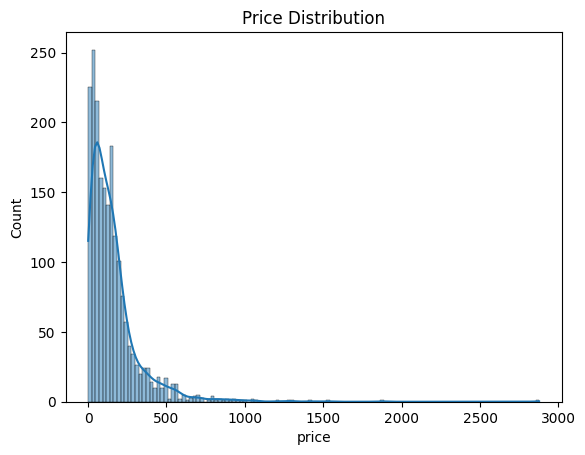

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()


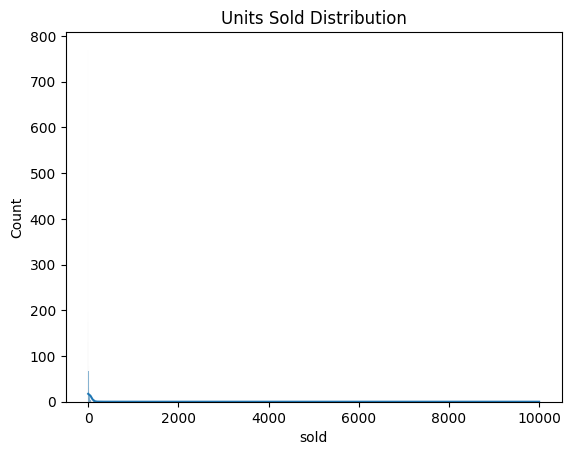

In [10]:
sns.histplot(df['sold'], kde=True)
plt.title("Units Sold Distribution")
plt.show()

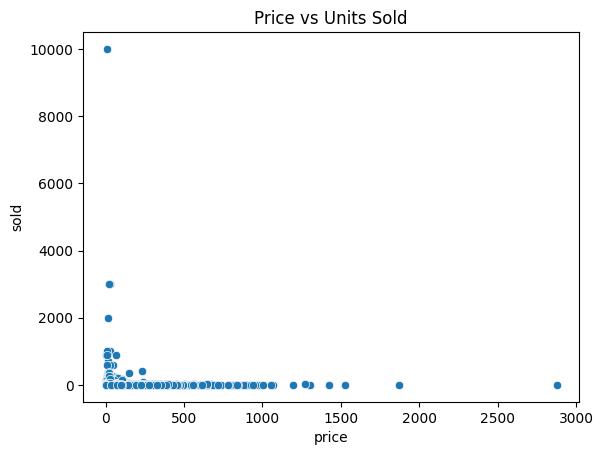

In [11]:
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Units Sold")
plt.show()

In [12]:
df['tagText'].value_counts()

,count
tagText,
Free shipping,1880
+Shipping: $5.09,9
+Shipping: $239.64,2
+Shipping: $80.21,2
+Shipping: $94.92,2
...,...
+Shipping: $134.27,1
+Shipping: $151.69,1
+Shipping: $41.93,1


In [13]:
df['tagText'] = df['tagText'].apply(
    lambda x: x if x in ['Free shipping', '+Shipping: $5.09'] else 'Others'
)

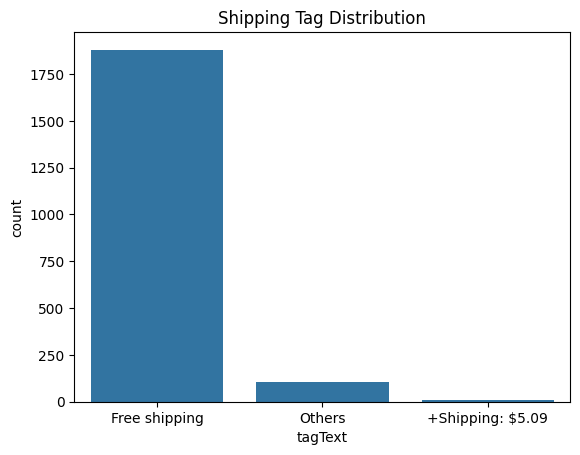

In [14]:
sns.countplot(x='tagText', data=df)
plt.title("Shipping Tag Distribution")
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['tagText'] = le.fit_transform(df['tagText'])

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=100, stop_words='english')
title_features = tfidf.fit_transform(df['productTitle'])

title_df = pd.DataFrame(
    title_features.toarray(),
    columns=tfidf.get_feature_names_out()
)

df = pd.concat([df.reset_index(drop=True), title_df], axis=1)
df.drop(columns=['productTitle'], inplace=True)


In [17]:
X = df.drop('sold', axis=1)
y = df['sold']

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)


LinearRegression()

In [20]:
from sklearn.metrics import mean_squared_error, r2_score


In [21]:
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)


In [23]:
print("Linear Regression → MSE:", mse_lr, "R2:", r2_lr)
# print("Random Forest → MSE:", mse_rf, "R2:", r2_rf) # Commented out as mse_rf and r2_rf are not defined

Linear Regression → MSE: 25195.408771682698 R2: 0.051728948868760116
